In [13]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

# BMI calculator

Body Mass Index (BMI) is a simple numerical value of your mass divided by the square of your height. It is used as a fast, low-cost tool to screen if a person has a body weight that falls into a healthy or risk range for their height



```bmi = weight / height(in metter)^2 ```

In [28]:
# define a state model for the BMI calculator graph

class BMICalculatorGraphState(BaseModel):
    weight: float
    height: float
    bmi: float = None


# class BMICalculatorGraphState(TypeDict):
#     weight: float
#     height: float
#     bmi: float = None

In [29]:
def bmi_calculator(state: BMICalculatorGraphState):
    weight = state.weight
    height = state.height

    bmi = weight / (height ** 2)
    state.bmi = bmi

    return state

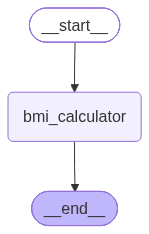

In [30]:
# initialize graph
graph_bmi_cal = StateGraph(BMICalculatorGraphState)

# create nodes
graph_bmi_cal.add_node("bmi_calculator", bmi_calculator)


# create edges
graph_bmi_cal.add_edge(START, "bmi_calculator")
graph_bmi_cal.add_edge("bmi_calculator", END)


# compile graph
graph_bmi_cal.compile()

In [31]:
# store compiled graph in a variable

final_graph = graph_bmi_cal.compile()

In [32]:
initial_state = BMICalculatorGraphState(weight=70, height=1.75)

output = final_graph.invoke(initial_state)

print(output)

{'weight': 70.0, 'height': 1.75, 'bmi': 22.857142857142858}


## Standard Weight Categories
- Underweight: Less than 18.5
- Healthy weight: 18.5 to 24.9
- Overweight: 25.0 to 29.9
- Obesity: 30.0 or higher



In [41]:
# define a state model for the Category Identifier graph
# extend the BMICalculatorGraphState to include a category field
class CategoryIdentifierGraphState(BMICalculatorGraphState):
    category: str = None
   

In [42]:
def identify_category(state: CategoryIdentifierGraphState):
    bmi = state.bmi

    if bmi < 18.5:
        state.category = "Underweight"
    elif 18.5 <= bmi < 24.9:
        state.category = "Normal weight"
    elif 25 <= bmi < 29.9:
        state.category = "Overweight"
    else:
        state.category = "Obesity"

    return state

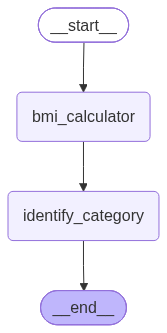

In [43]:
# initialize graph
graph_category_identifier = StateGraph(CategoryIdentifierGraphState)

# add nodes
graph_category_identifier.add_node("bmi_calculator", bmi_calculator)
graph_category_identifier.add_node("identify_category", identify_category)

# add edges
graph_category_identifier.add_edge(START, "bmi_calculator")
graph_category_identifier.add_edge("bmi_calculator", "identify_category")
graph_category_identifier.add_edge("identify_category", END)

# compile graph
graph_category_identifier.compile()

In [46]:
# store compiled graph in a variable
final_graph_category_identifier = graph_category_identifier.compile()

In [47]:
# invoke the graph runnable with an initial state
initial_state_category_identifier = CategoryIdentifierGraphState(weight=70, height=1.75)

result_category_identifier = final_graph_category_identifier.invoke(initial_state_category_identifier)

print(result_category_identifier)

{'weight': 70.0, 'height': 1.75, 'bmi': 22.857142857142858, 'category': 'Normal weight'}


{
   "properties": {
      "weight": {
         "title": "Weight",
         "type": "number"
      },
      "height": {
         "title": "Height",
         "type": "number"
      },
      "bmi": {
         "default": null,
         "title": "Bmi",
         "type": "number"
      },
      "category": {
         "default": null,
         "title": "Category",
         "type": "string"
      }
   },
   "required": [
      "weight",
      "height"
   ],
   "title": "CategoryIdentifierGraphState",
   "type": "object"
}


/tmp/ipykernel_16171/3918882728.py:1: PydanticDeprecatedSince20: The `schema_json` method is deprecated; use `model_json_schema` and json.dumps instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  print(CategoryIdentifierGraphState.schema_json(indent=3))
